In [3]:
# ============================================================
# BUSINESS INTELLIGENCE MINI PROJECT
# Customer Status Classification
# ============================================================

# ============================================================
# STEP 1 : Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    
)

from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [4]:
# ============================================================
# STEP 2 : Load the Dataset
# ============================================================

# Load the cleaned customer dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Downloads\\Cleaned_Customer_Data.csv")

# Display the first five records
df.head()
# ============================================================
# STEP 3 : Dataset Overview
# ============================================================

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns)

print("\n")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\n")

print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

df.describe().T



DATASET SHAPE
(7043, 36)


COLUMN NAMES
Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status'],
      dtype='str')


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------             

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000
Monthly Charge,7043.0,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000


In [3]:
# ============================================================
# STEP 4 : Problem Definition
# ============================================================

print("=" * 70)
print("PROBLEM DEFINITION")
print("=" * 70)

print("""
Business Problem:
A telecom company wants to predict the current status of its customers
using demographic, service usage, and billing information.

Machine Learning Task:
Multi-Class Classification

Target Variable:
Customer Status

Classes:
1. Stayed
2. Churned
3. Joined

Objective:
Develop classification models that accurately predict the customer
status and identify the most influential factors affecting customer
retention and churn.
""")

PROBLEM DEFINITION

Business Problem:
A telecom company wants to predict the current status of its customers
using demographic, service usage, and billing information.

Machine Learning Task:
Multi-Class Classification

Target Variable:
Customer Status

Classes:
1. Stayed
2. Churned
3. Joined

Objective:
Develop classification models that accurately predict the customer
status and identify the most influential factors affecting customer
retention and churn.



Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Percentage Distribution

Customer Status
Stayed     67.02
Churned    26.54
Joined      6.45
Name: proportion, dtype: float64


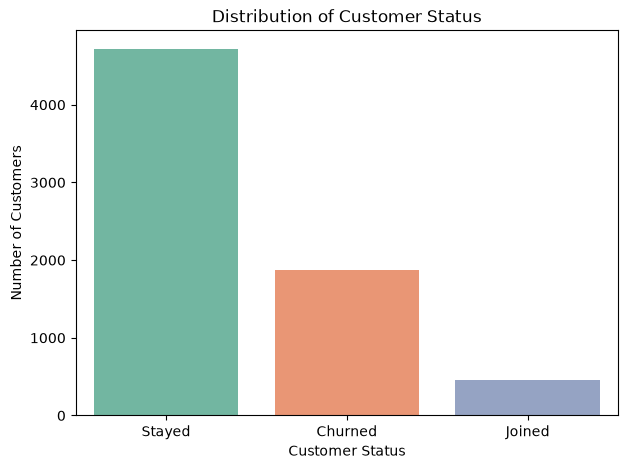

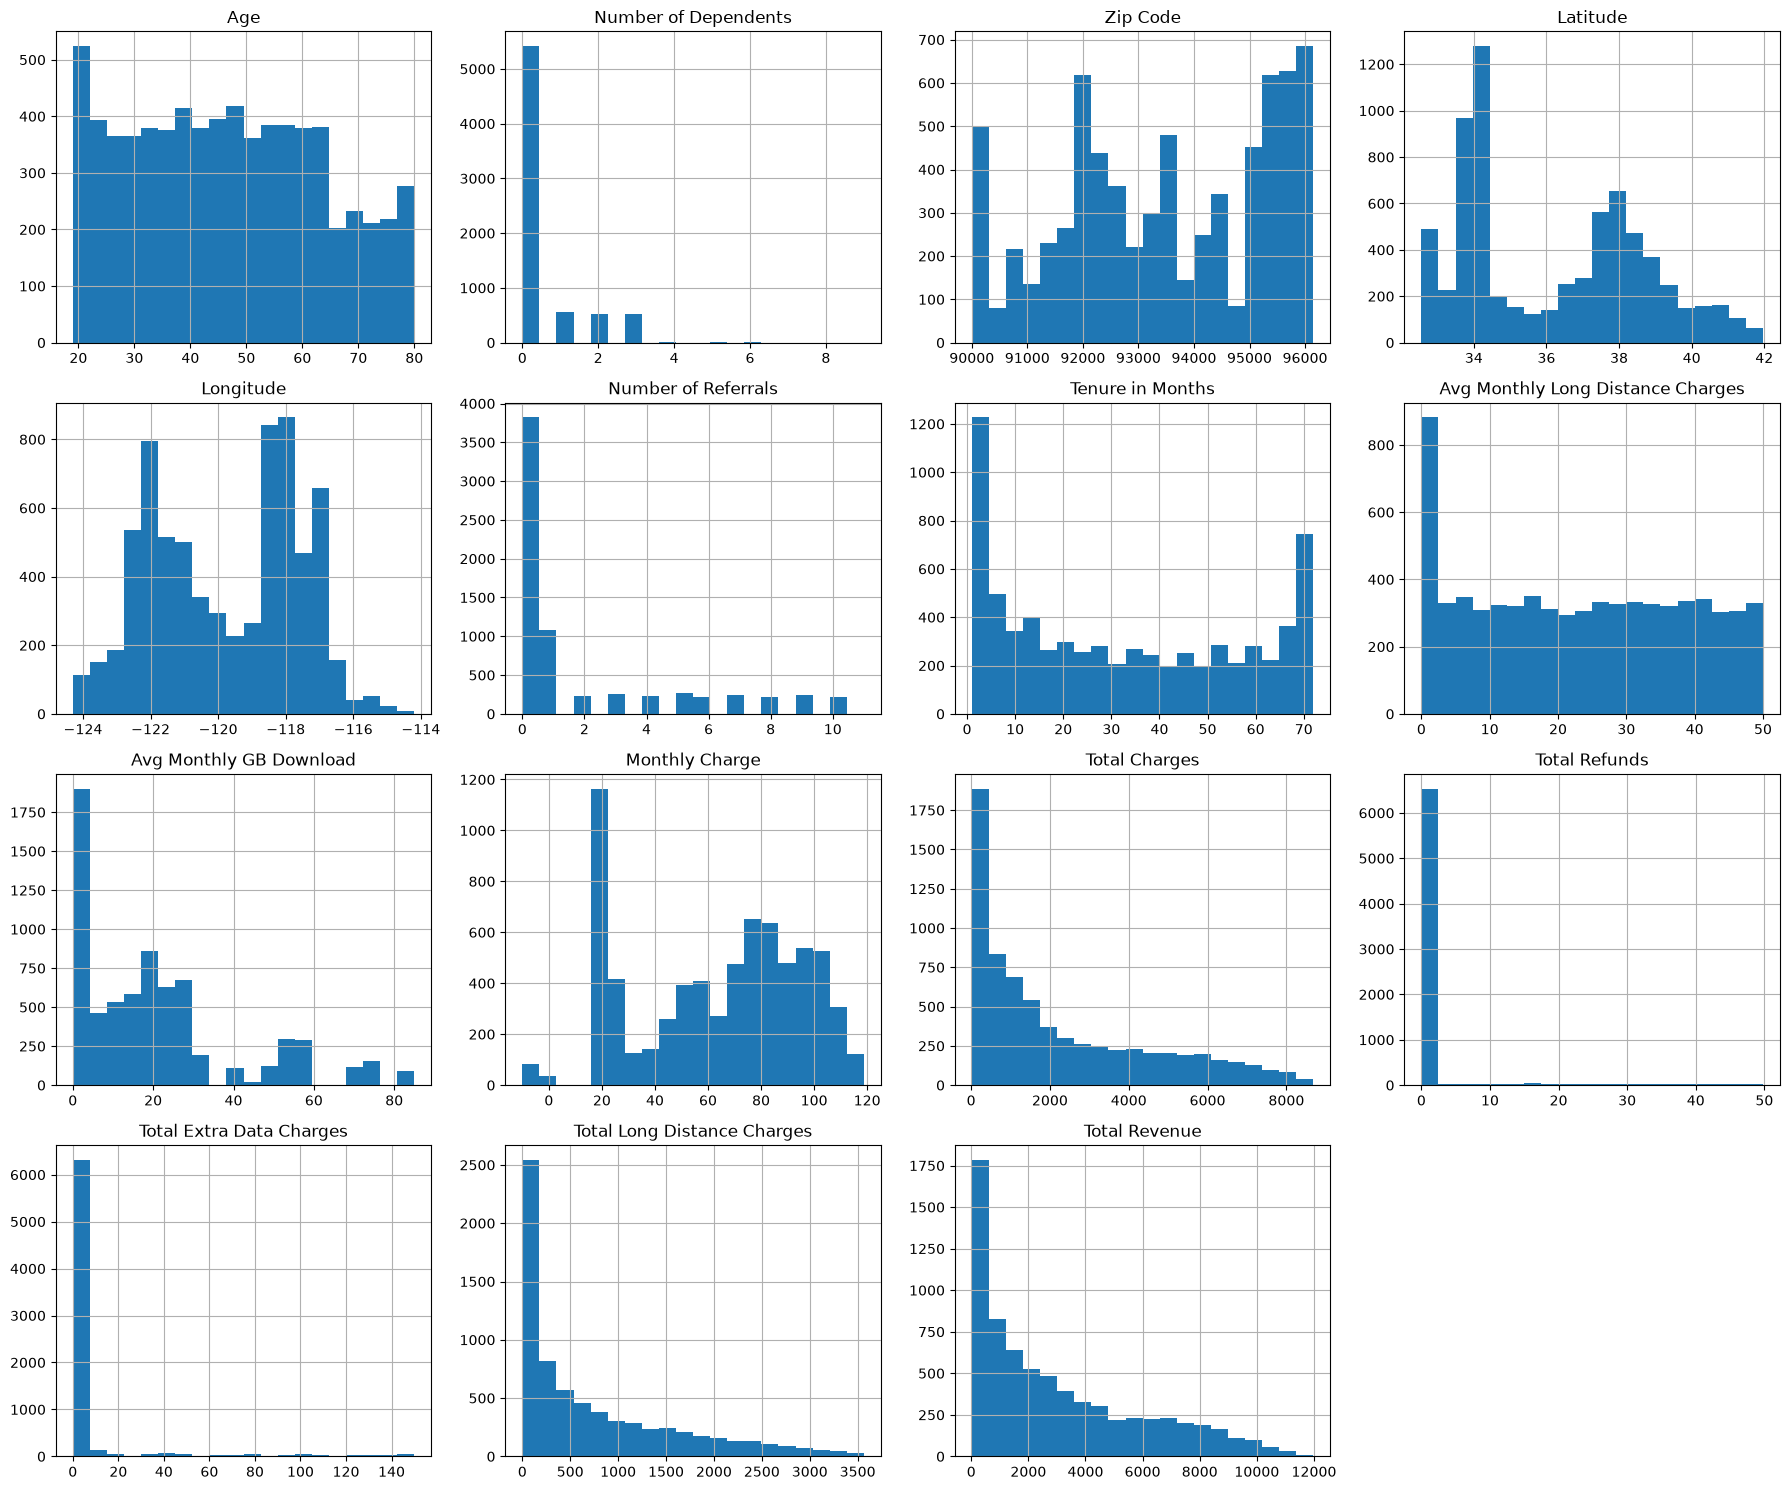

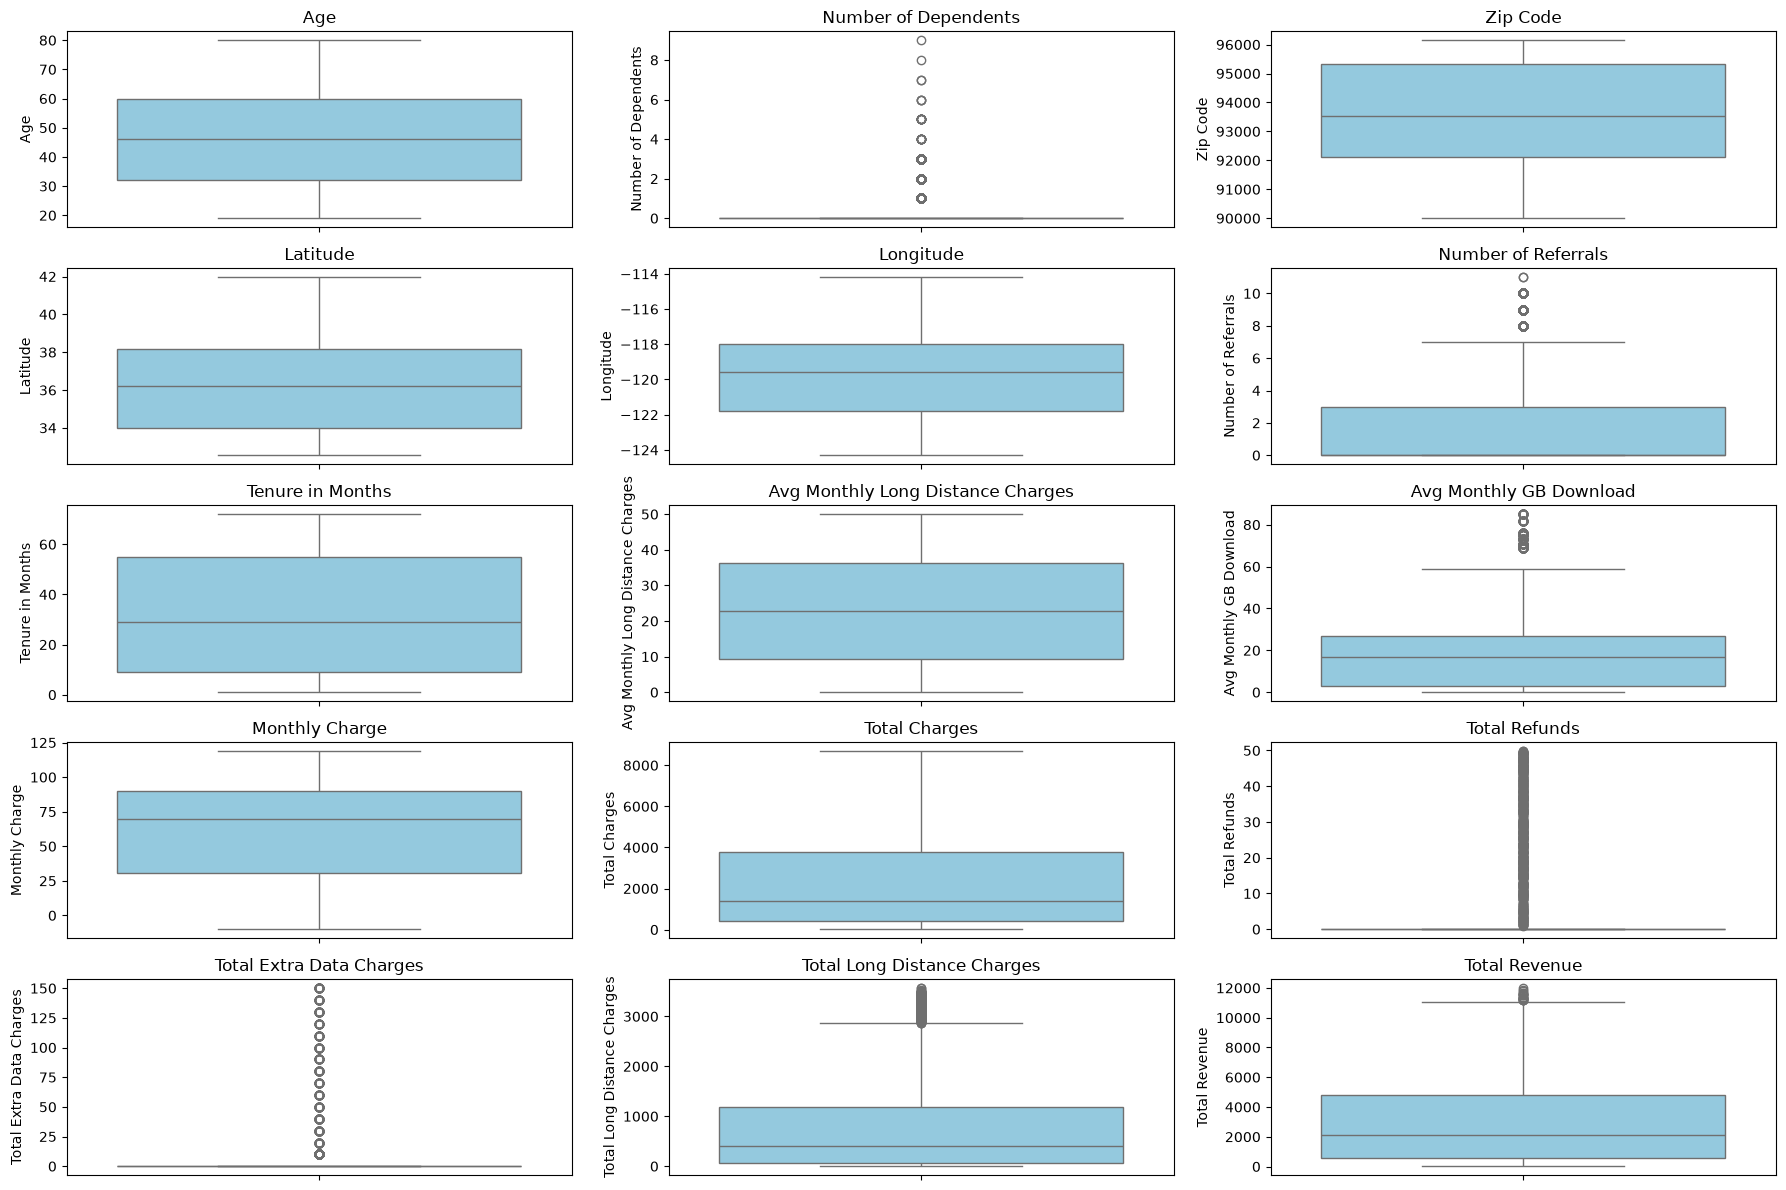

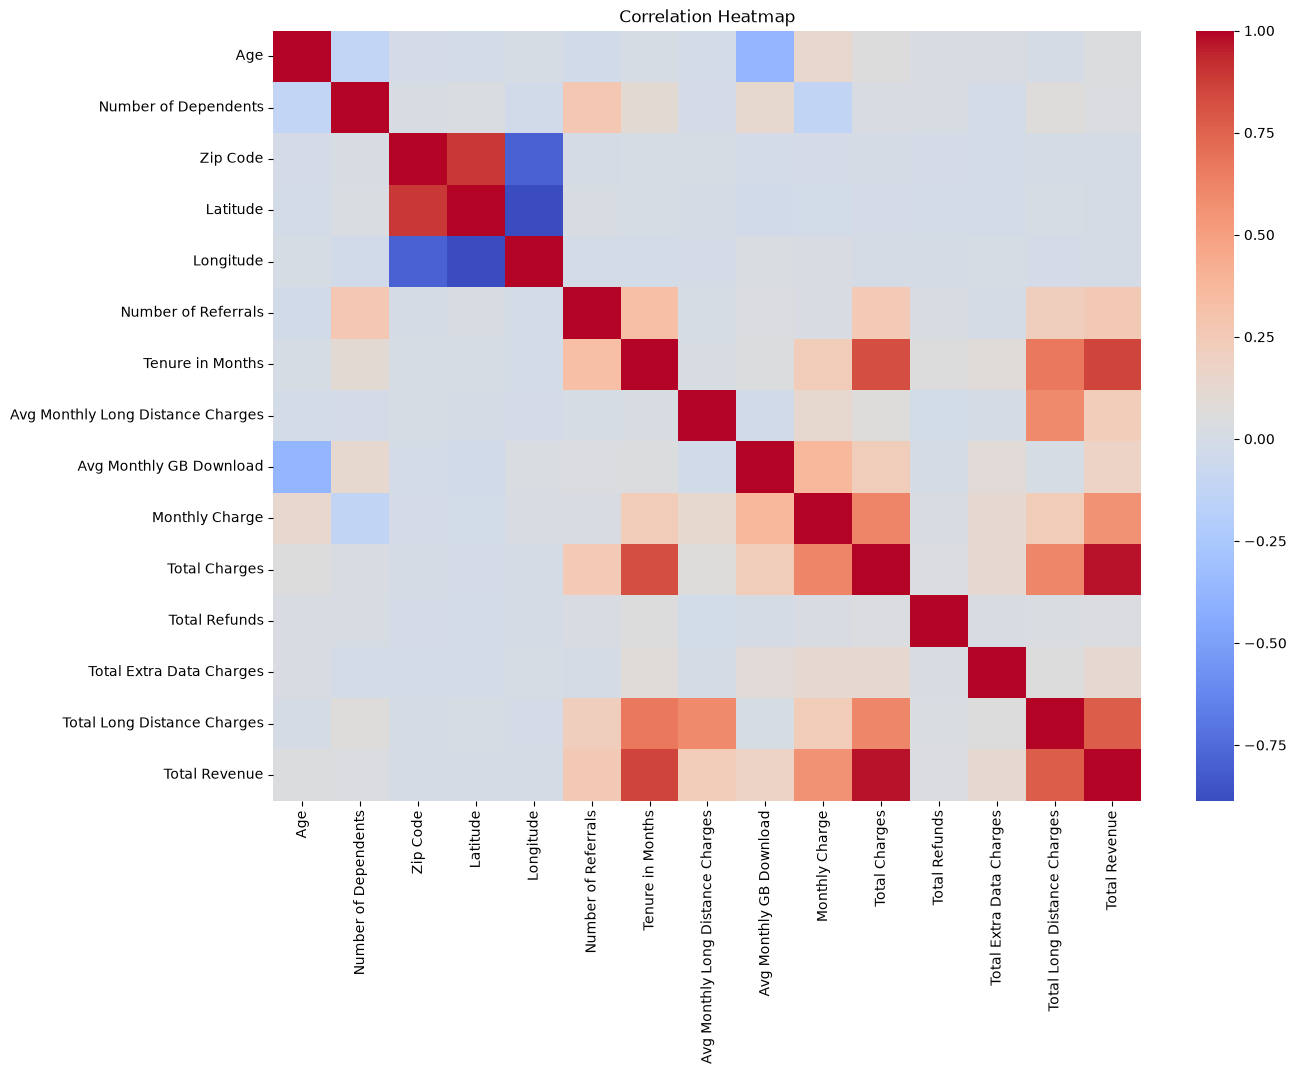

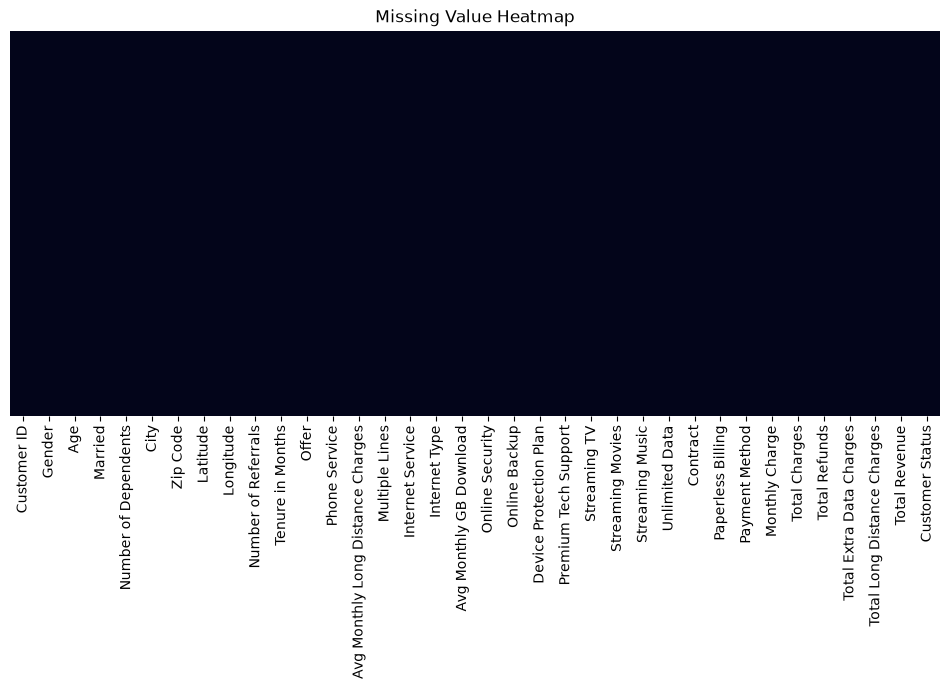

In [5]:
# ============================================================
# STEP 5.1 : Target Variable Distribution
# ============================================================

print(df["Customer Status"].value_counts())

print("\nPercentage Distribution\n")

print(round(df["Customer Status"].value_counts(normalize=True)*100,2))

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Customer Status",
    palette="Set2"
)

plt.title("Distribution of Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()
# ============================================================
# STEP 5.2 : Distribution of Numerical Features
# ============================================================

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numerical_columns].hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()

plt.show()
# ============================================================
# STEP 5.3 : Boxplots for Numerical Features
# ============================================================

plt.figure(figsize=(18,12))

for i, column in enumerate(numerical_columns):

    plt.subplot(5,3,i+1)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()
# ============================================================
# STEP 5.4 : Correlation Heatmap
# ============================================================

plt.figure(figsize=(14,10))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()
# ============================================================
# STEP 5.5 : Missing Value Visualization
# ============================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show()


In [6]:
# ============================================================
# STEP 6 : Duplicate Records
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records :", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records detected.")


# ============================================================
# STEP 7 : Missing Values
# ============================================================

missing = df.isnull().sum()

print(missing)

print("\n")

print("Total Missing Values :", missing.sum())

Number of Duplicate Records : 0
No duplicate records found.
Customer ID                          0
Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Stre

FEATURE ENGINEERING

No additional feature engineering was performed.

Reason:
- The dataset was already preprocessed.
- No date attributes were available for extracting new features.
- Existing variables were already meaningful for the classification task.

Target Distribution
Customer Status
0    5174
1    1869
Name: count, dtype: int64

0 = Not Churned
1 = Churned
Training Features : (5634, 34)
Testing Features  : (1409, 34)

Training Labels : (5634,)
Testing Labels  : (1409,)
Categorical Columns : 19
Numerical Columns   : 15
Training Shape : (5634, 1170)
Testing Shape  : (1409, 1170)


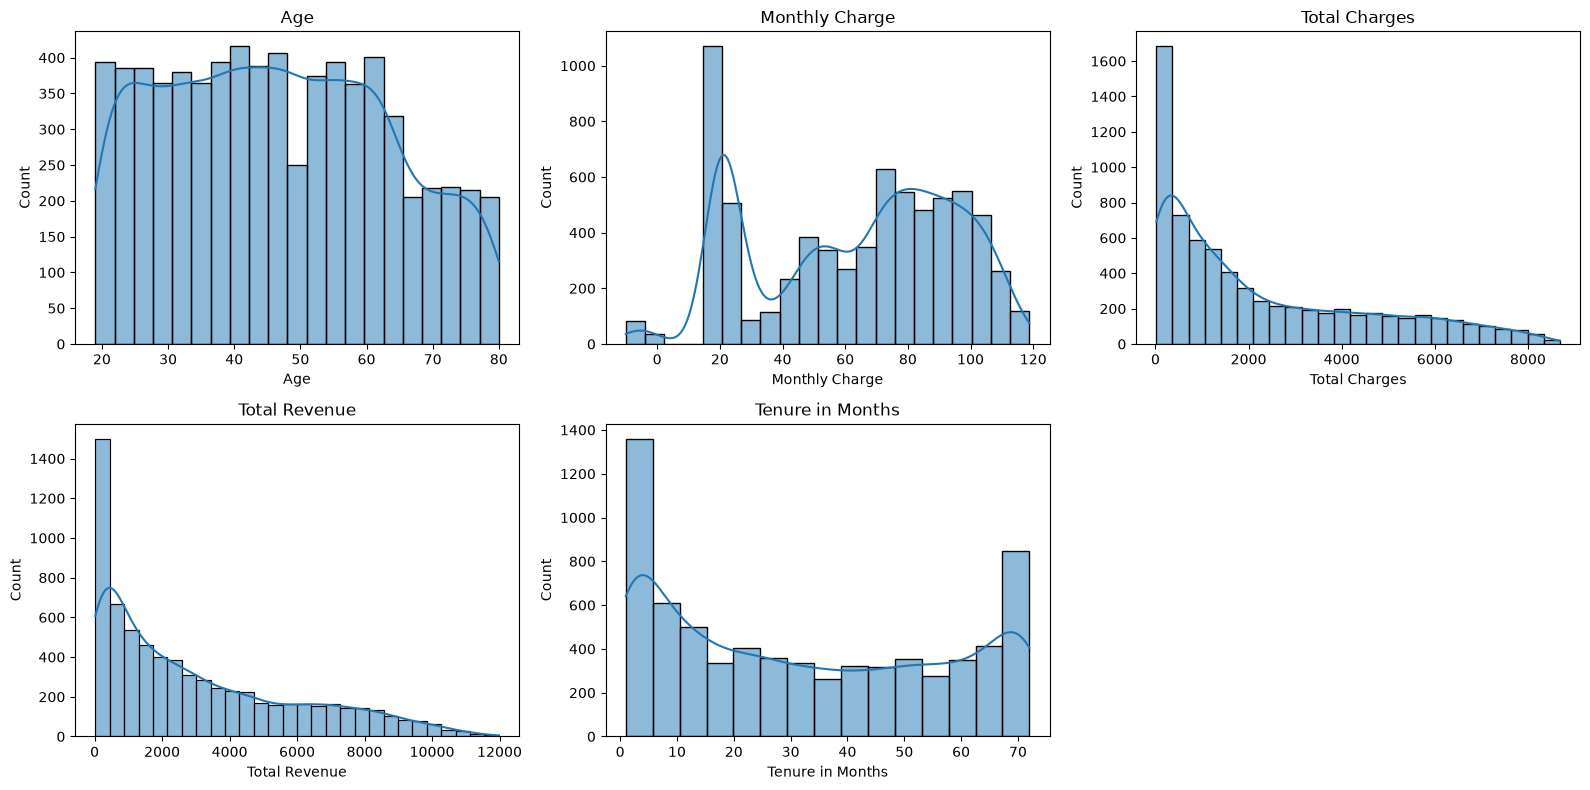

In [8]:
# ============================================================
# STEP 8 : Basic Feature Engineering
# ============================================================

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

print("""
No additional feature engineering was performed.

Reason:
- The dataset was already preprocessed.
- No date attributes were available for extracting new features.
- Existing variables were already meaningful for the classification task.
""")

# ============================================================
# STEP 9 : Train-Test Split
# ============================================================

# Remove Customer ID (identifier only)
data = df.drop(columns=["Customer ID"])

# ============================================================
# STEP 9 : Define Features and Binary Target
# ============================================================

# Remove Customer ID
data = df.drop(columns=["Customer ID"])

# Features
X = data.drop(columns=["Customer Status"])

# Binary Target
# Churned = 1
# Stayed and Joined = 0

y = data["Customer Status"].apply(
    lambda x: 1 if x == "Churned" else 0
)

print("Target Distribution")

print(y.value_counts())

print()

print("0 = Not Churned")
print("1 = Churned")

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

# ============================================================
# STEP 10 : Missing Value Imputation
# ============================================================

categorical_columns = X_train.select_dtypes(include="object").columns

numerical_columns = X_train.select_dtypes(exclude="object").columns

print("Categorical Columns :", len(categorical_columns))
print("Numerical Columns   :", len(numerical_columns))

# ============================================================
# STEP 11 : One-Hot Encoding
# ============================================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_columns),
    ("num", numerical_pipeline, numerical_columns)
])

# Learn only from training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply the learned encoding to test data
X_test_encoded = preprocessor.transform(X_test)

print("Training Shape :", X_train_encoded.shape)
print("Testing Shape  :", X_test_encoded.shape)

# ============================================================
# STEP 12 : Numerical Feature Distribution
# ============================================================

important_features = [
    "Age",
    "Monthly Charge",
    "Total Charges",
    "Total Revenue",
    "Tenure in Months"
]

plt.figure(figsize=(16,8))

for i, feature in enumerate(important_features):

    plt.subplot(2,3,i+1)

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# STEP 13 : Feature Scaling
# ============================================================

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)

X_test_scaled = scaler.transform(X_test_encoded)

print("Scaling Completed Successfully")
# ============================================================
# STEP 14 : Class Imbalance Check
# ============================================================



print("Training Class Distribution")

print("Not Churned :", (y_train == 0).sum())
print("Churned     :", (y_train == 1).sum())


Scaling Completed Successfully
Training Class Distribution
Not Churned : 4139
Churned     : 1495


Logistic Regression Model Trained Successfully!
LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.7842
Precision : 0.7811
Recall    : 0.7842
F1 Score  : 0.7825

Classification Report

              precision    recall  f1-score   support

 Not Churned       0.85      0.86      0.85      1035
     Churned       0.60      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



<Figure size 700x600 with 0 Axes>

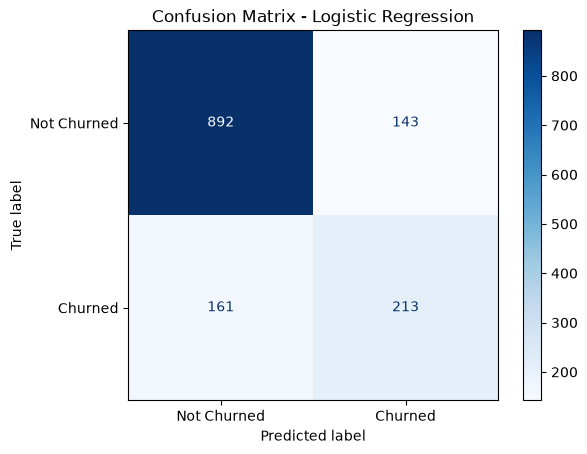

In [14]:
# ============================================================
# STEP 15 : Logistic Regression Model
# ============================================================

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Model Trained Successfully!")


# ============================================================
# STEP 16 : Logistic Regression Evaluation
# ============================================================

# Predict customer status
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

# Evaluation Metrics
accuracy = accuracy_score(y_test, logistic_predictions)

precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

print("="*60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Not Churned", "Churned"]
)
    )


# ============================================================
# Logistic Regression Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

plt.figure(figsize=(7,6))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Random Forest Model Trained Successfully!
RANDOM FOREST PERFORMANCE
Accuracy  : 0.8325
Precision : 0.8253
Recall    : 0.8325
F1 Score  : 0.8245

Classification Report

              precision    recall  f1-score   support

 Not Churned       0.86      0.93      0.89      1035
     Churned       0.74      0.56      0.64       374

    accuracy                           0.83      1409
   macro avg       0.80      0.75      0.77      1409
weighted avg       0.83      0.83      0.82      1409



<Figure size 700x600 with 0 Axes>

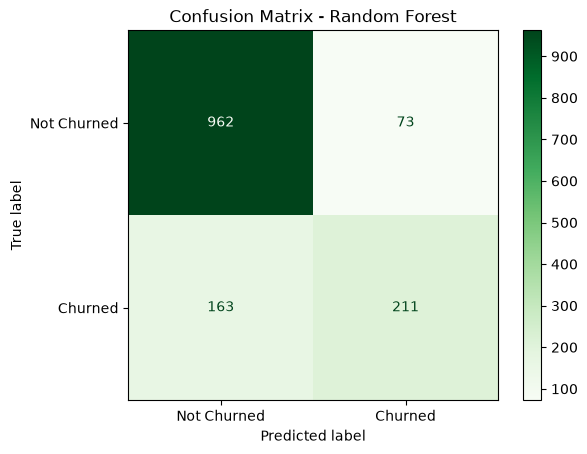

TOP 10 IMPORTANT FEATURES
                               Feature  Importance
1165                num__Total Charges    0.048413
1147      cat__Contract_Month-to-Month    0.047851
1169                num__Total Revenue    0.045743
1161             num__Tenure in Months    0.045688
1168  num__Total Long Distance Charges    0.041617
1160          num__Number of Referrals    0.038082
1164               num__Monthly Charge    0.037275
1155                          num__Age    0.034685
1158                     num__Latitude    0.033309
1159                    num__Longitude    0.032375


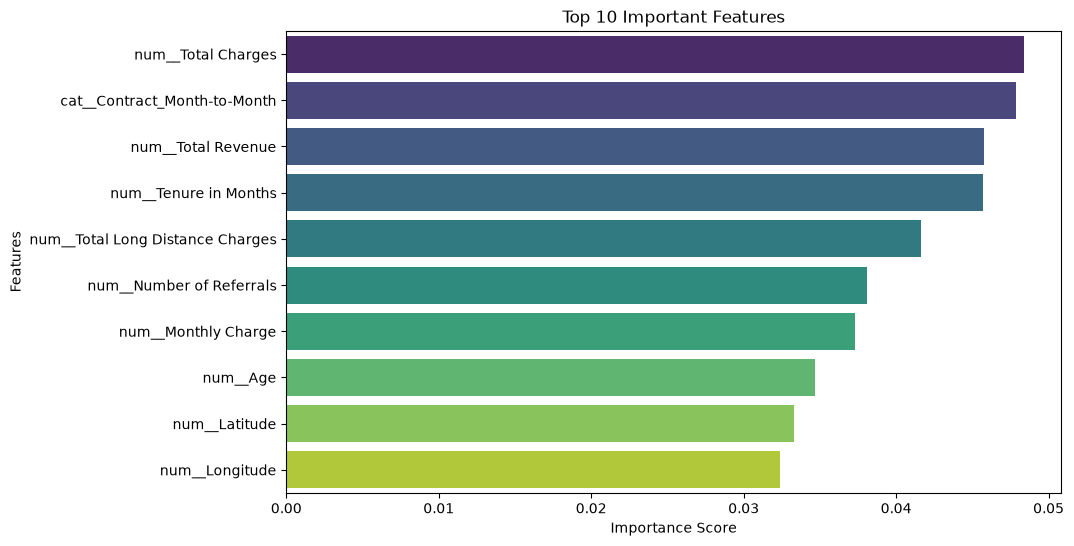

In [20]:
# ============================================================
# STEP 17 : Random Forest Classifier
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Random Forest
rf_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest Model Trained Successfully!")

# ============================================================
# STEP 18 : Random Forest Evaluation
# ============================================================

rf_predictions = rf_model.predict(
    X_test_encoded
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("="*60)
print("RANDOM FOREST PERFORMANCE")
print("="*60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Not Churned", "Churned"]
    )
)

# ============================================================
# Random Forest Confusion Matrix
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Churned", "Churned"]
)

plt.figure(figsize=(7,6))

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")

plt.show()

# ============================================================
# STEP 19 : Feature Importance
# ============================================================

# Retrieve feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance scores
importance = rf_model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*60)
print("TOP 10 IMPORTANT FEATURES")
print("="*60)

print(feature_importance.head(10))

# Plot Top 10 Features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [21]:
# ============================================================
# STEP 20 : Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        rf_precision
    ],

    "Recall": [
        recall,
        rf_recall
    ],

    "F1 Score": [
        f1,
        rf_f1
    ]

})

print("=" * 70)
print("CLASSIFICATION MODEL COMPARISON (CHURN PREDICTION)")
print("=" * 70)

print(comparison)


# ============================================================
# STEP 21 : Final Business Interpretation
# ============================================================

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""

1. Random Forest achieved better predictive performance
   than Logistic Regression for customer churn prediction.

2. Customer tenure was one of the strongest predictors
   of customer churn.

3. Revenue-related variables such as Total Charges,
   Total Revenue, and Monthly Charge significantly
   influenced the likelihood of customer churn.

4. Customers with shorter tenure showed a higher
   probability of churning, whereas long-term
   customers were generally more loyal.

5. The developed classification model can help the
   telecom company identify customers who are likely
   to churn, allowing proactive retention strategies,
   personalized offers, and improved customer
   relationship management.

6. The comparison of both models indicates that
   Random Forest is the preferred model due to its
   superior Accuracy, Precision, Recall, and F1 Score
   for predicting customer churn.

""")


# ============================================================
# STEP 22 : Conclusion
# ============================================================

print("=" * 70)
print("CONCLUSION")
print("=" * 70)

print("""

This study developed machine learning models to predict
whether a telecom customer is likely to churn.

Two classification algorithms, Logistic Regression and
Random Forest, were implemented and evaluated using
Accuracy, Precision, Recall, and F1 Score.

Among the two models, Random Forest demonstrated the
best overall performance and was selected as the final
model for churn prediction.

The analysis also showed that customer tenure,
monthly charges, total charges, and total revenue
were the most influential factors affecting customer
churn.

The developed model can support telecom companies in
identifying at-risk customers and implementing targeted
retention strategies to reduce customer churn and
improve long-term profitability.

""")

CLASSIFICATION MODEL COMPARISON (CHURN PREDICTION)
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.784244   0.781066  0.784244  0.782514
1        Random Forest  0.832505   0.825342  0.832505  0.824540
BUSINESS INSIGHTS


1. Random Forest achieved better predictive performance
   than Logistic Regression for customer churn prediction.

2. Customer tenure was one of the strongest predictors
   of customer churn.

3. Revenue-related variables such as Total Charges,
   Total Revenue, and Monthly Charge significantly
   influenced the likelihood of customer churn.

4. Customers with shorter tenure showed a higher
   probability of churning, whereas long-term
   customers were generally more loyal.

5. The developed classification model can help the
   telecom company identify customers who are likely
   to churn, allowing proactive retention strategies,
   personalized offers, and improved customer
   relationship management.

6. The comparison of b